In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from src.counting import detect_shapes, draw_result

CLASSES = ["circle", "triangle", "square", "pentagon", "hexagon"]
MINIMAL = ["n_vertices_4", "circle_fill", "rect_fill", "rect_aspect", "hu1"]

feats = pd.read_csv("data/processed/features.csv")
tr = feats[feats.split == "train"]
model = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                               random_state=0).fit(tr[MINIMAL], tr.label)

scenes = pd.read_csv("data/generated/scenes_metadata.csv")


def run(split_df):
    rows = []
    for r in split_df.itertuples():
        img = cv2.imread(r.path)
        res = detect_shapes(img, model, MINIMAL)
        pred = Counter(label for _, label in res)
        row = {"path": r.path, "true_total": r.total_count, "pred_total": len(res)}
        for c in CLASSES:
            row[f"true_{c}"] = getattr(r, f"n_{c}")
            row[f"pred_{c}"] = pred.get(c, 0)
        rows.append(row)
    return pd.DataFrame(rows)


def report(d, name):
    print(f"--- {name} ({len(d)} scenes) ---")
    print("total count exact match:", (d.true_total == d.pred_total).mean().round(3))
    print("total count MAE:", (d.true_total - d.pred_total).abs().mean().round(3))
    per = {c: {"exact": (d[f"true_{c}"] == d[f"pred_{c}"]).mean(),
               "MAE": (d[f"true_{c}"] - d[f"pred_{c}"]).abs().mean()} for c in CLASSES}
    print(pd.DataFrame(per).T.round(3))
    allok = np.all([d[f"true_{c}"] == d[f"pred_{c}"] for c in CLASSES], axis=0).mean()
    print("scenes with every per-class count right:", round(allok, 3))


train_scenes = run(scenes[scenes.split == "train"])
test_scenes = run(scenes[scenes.split == "test"])
report(train_scenes, "train scenes")
report(test_scenes, "test scenes")
test_scenes.to_csv("outputs/counting_results.csv", index=False)

--- train scenes (100 scenes) ---
total count exact match: 1.0
total count MAE: 0.0
          exact  MAE
circle      1.0  0.0
triangle    1.0  0.0
square      1.0  0.0
pentagon    1.0  0.0
hexagon     1.0  0.0
scenes with every per-class count right: 1.0
--- test scenes (40 scenes) ---
total count exact match: 1.0
total count MAE: 0.0
          exact  MAE
circle      1.0  0.0
triangle    1.0  0.0
square      1.0  0.0
pentagon    1.0  0.0
hexagon     1.0  0.0
scenes with every per-class count right: 1.0


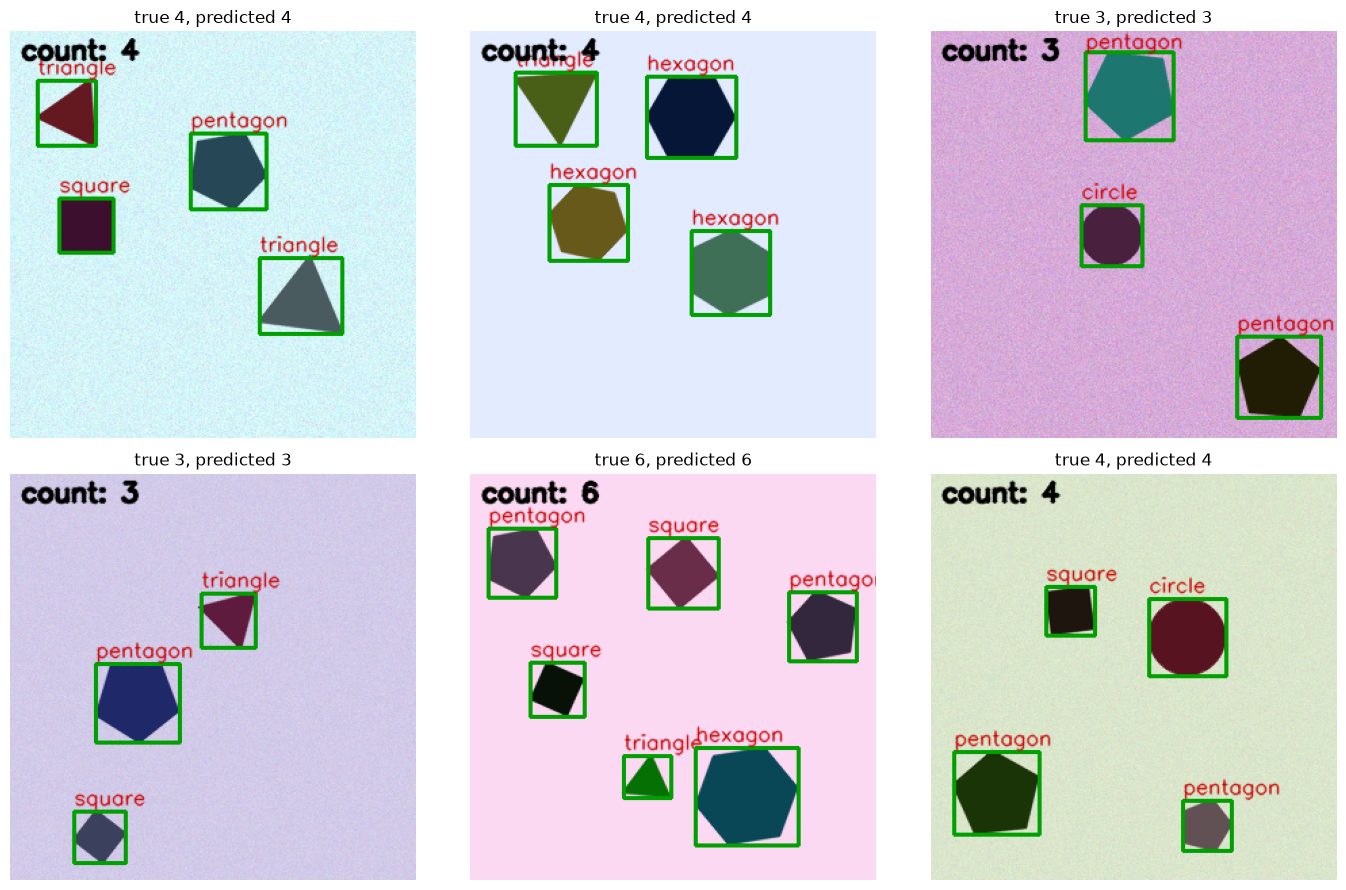

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, r in zip(axes.ravel(), test_scenes.head(6).itertuples()):
    img = cv2.imread(r.path)
    out = draw_result(img, detect_shapes(img, model, MINIMAL))
    ax.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
    ax.set_title(f"true {r.true_total}, predicted {r.pred_total}")
    ax.axis("off")
plt.tight_layout()
fig.savefig("outputs/counting_demo.png", dpi=150, bbox_inches="tight")
plt.show()